### Comparing Aggregate Models for Classification

This try-it focuses on utilizing ensemble models in a classification setting.  Much like you have used individual regression estimators to form an ensemble of estimators -- here your goal is to explore ensembles for classification models.  You will use scikitlearn to carry out the ensemble using the `VotingClassifier`.


#### Dataset and Task

Below, the plasma lipidomics dataset is loaded and filtered to the MCI patients with a known progression outcome. Your task is to use ensemble methods to explore predicting the `Target` column -- whether the patient progressed from Mild Cognitive Impairment to Alzheimer's Disease (Yes/No) -- from their CSF biomarkers (amyloid, total tau, phosphorylated tau), MMSE cognitive score, and demographics (age, sex, APOE4 status).  Your ensemble should at the very least consider the following models:

- `LogisticRegression`
- `KNeighborsClassifier`
- `DecisionTreeClassifier`
- `RidgeClassifier`
- `SVC`

Tune the `VotingClassifier` to try to optimize the prediction performance and determine if the wisdom of the crowd performed better in this setting than any of the individual models themselves.  Report back on your findings and discuss the interpretability of your findings.  Is there a way to determine what features mattered in predicting progression to Alzheimer's Disease?

In [27]:
import pandas as pd
import seaborn as sns
sns.set_palette("pastel")
import plotly.express as px
import matplotlib.pyplot as plt
import math
import numpy as np

from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, make_scorer
)
from sklearn.inspection import permutation_importance

In [4]:
# 1. Load data, keep only patients with a known outcome (MCI patients)
df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df["Progression to Alzheimer's Disease"].notna()].copy()

# 2. Fill missing numeric values with the column median
numeric_cols = ['Age', 'MMSE', 'CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)',
                 'CSF Phosphorylated tau (pg/mL)']
for col in numeric_cols:
    median_val = mci[col].median()
    mci[col] = mci[col].fillna(median_val)

# 3. Fill missing categorical values with the most common value
mode_val = mci['APOE4'].mode()[0]
mci['APOE4'] = mci['APOE4'].fillna(mode_val)

# 4. Convert categorical text columns to numeric (0/1)
mci['Sex'] = (mci['Sex'] == 'Male').astype(int)          # Male=1, Female=0
mci['APOE4'] = (mci['APOE4'] == 'Yes').astype(int)        # carries APOE4 allele=1, no=0
mci['Target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
df = mci.copy()
df = df.rename(columns={'CSF Amyloid (pg/mL)': 'amyloid', 'CSF Phosphorylated tau (pg/mL)': 'tau', "Progression to Alzheimer's Disease" : 'progression'})

In [5]:
# Display the first few rows to understand the data
df.head()

,Sample,Diagnostic,Sex,Age,MMSE,amyloid,CSF Total tau (pg/mL),tau,APOE4,progression,Progression time (months),Target
64,65,Mild Cognitive Impairment,1,69,23,595.0,465.0,75.0,0,No,NaN,0
104,105,Mild Cognitive Impairment,1,70,27,1845.0,353.0,92.4,0,No,NaN,0
105,106,Mild Cognitive Impairment,0,73,29,928.0,531.0,176.0,0,No,NaN,0
106,107,Mild Cognitive Impairment,0,68,23,619.0,477.0,142.0,1,Yes,14.0,1
107,108,Mild Cognitive Impairment,1,78,27,784.0,1231.0,394.0,0,No,NaN,0


## Cleaning

In [6]:
# Build the modeling frame: predict Target (Progression to Alzheimer's Disease: 1 = Yes, 0 = No)
# from CSF biomarkers, MMSE cognitive score, and demographics
model_df = df[['Age', 'MMSE', 'amyloid', 'CSF Total tau (pg/mL)', 'tau', 'Sex', 'APOE4', 'Target']].copy()
model_df = model_df.rename(columns={
    'Age': 'age',
    'MMSE': 'mmse',
    'CSF Total tau (pg/mL)': 'total_tau',
    'Sex': 'sex',
    'APOE4': 'apoe4'
})

# already cleaned and imputed above; no missing values remain
model_df.isnull().sum()

age          0
mmse         0
amyloid      0
total_tau    0
tau          0
sex          0
apoe4        0
Target       0
dtype: int64

## Separate for Training

In [7]:
# Separate features and target variable
X = model_df.drop(columns=['Target'])
y = model_df['Target']

# sex and apoe4 are already 0/1 encoded, no dummy variables needed

# Split the data into training and testing sets (stratify to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## Models

In [8]:
# Define individual classifiers
models = {
    'Logistic Regression': Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    'Random Forest':        RandomForestClassifier(n_estimators=300, random_state=42),
    'SVM (RBF)':            Pipeline([('sc', StandardScaler()), ('clf', SVC(probability=True, random_state=42))]),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=42),
    'K-Nearest Neighbors':  Pipeline([('sc', StandardScaler()), ('clf', KNeighborsClassifier())]),
    'LDA':                  Pipeline([('sc', StandardScaler()), ('clf', LinearDiscriminantAnalysis())]),
    'Naive Bayes':          Pipeline([('sc', StandardScaler()), ('clf', GaussianNB())]),
}

# Define the Voting Classifier (soft voting: every base model supports predict_proba)
voting_clf = VotingClassifier(estimators=list(models.items()), voting='soft')

# Function to evaluate models. We're concerned about false negatives (missed progressors),
# so we track recall and the F2 score (weights recall twice as heavily as precision)
# alongside accuracy, precision, F1, and ROC-AUC rather than reporting accuracy alone.
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'f2': fbeta_score(y_test, y_pred, beta=2, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_proba),
    }

In [28]:
# Evaluate individual models without grid search
results_before_gs = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    results_before_gs[name] = evaluate_model(model, X_test, y_test)

results_before_gs_df = pd.DataFrame(results_before_gs).T
print("Results Before Grid Search:")
results_before_gs_df

Results Before Grid Search:


,accuracy,precision,recall,f1,f2,roc_auc
Logistic Regression,0.555556,0.600000,0.6,0.600000,0.600000,0.7750
Random Forest,0.777778,0.875000,0.7,0.777778,0.729167,0.7250
SVM (RBF),0.722222,0.777778,0.7,0.736842,0.714286,0.7375
Gradient Boosting,0.666667,0.666667,0.8,0.727273,0.769231,0.7375
K-Nearest Neighbors,0.777778,0.800000,0.8,0.800000,0.800000,0.7500
LDA,0.611111,0.666667,0.6,0.631579,0.612245,0.7500
Naive Bayes,0.666667,0.700000,0.7,0.700000,0.700000,0.7625


In [29]:
# Evaluate Voting Classifier without grid search
voting_clf.fit(X_train, y_train)
voting_results_before_gs = evaluate_model(voting_clf, X_test, y_test)

In [11]:
# Add the voting classifier's results to the comparison table
results_before_gs_df.loc['Voting Classifier'] = voting_results_before_gs
results_before_gs_df

,accuracy,precision,recall,f1,f2,roc_auc
Logistic Regression,0.555556,0.600000,0.6,0.600000,0.600000,0.7750
Random Forest,0.777778,0.875000,0.7,0.777778,0.729167,0.7250
SVM (RBF),0.722222,0.777778,0.7,0.736842,0.714286,0.7375
Gradient Boosting,0.666667,0.666667,0.8,0.727273,0.769231,0.7375
K-Nearest Neighbors,0.777778,0.800000,0.8,0.800000,0.800000,0.7500
LDA,0.611111,0.666667,0.6,0.631579,0.612245,0.7500
Naive Bayes,0.666667,0.700000,0.7,0.700000,0.700000,0.7625
Voting Classifier,0.722222,0.777778,0.7,0.736842,0.714286,0.7625


## 

## GridSearchCV

In [30]:

# Define parameter grids for Grid Search
param_grids = {
    'Logistic Regression': {'clf__C': [0.1, 1.0, 10.0]},
    'Random Forest': {'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 2, 4]},
    'SVM (RBF)': {'clf__C': [0.1, 1.0, 10.0], 'clf__gamma': ['scale', 'auto']},
    'Gradient Boosting': {'n_estimators': [100, 200], 'max_depth': [2, 3], 'learning_rate': [0.05, 0.1]},
    'K-Nearest Neighbors': {'clf__n_neighbors': [3, 5, 7]},
    'LDA': {},
    'Naive Bayes': {},
}

# Score on F2 (weights recall 2x precision) since missed progressors (false negatives)
# are the costlier error here -- picking hyperparameters on accuracy alone can favor
# models that quietly under-predict the positive class.
f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

# Perform Grid Search and evaluate models
results_after_gs = {}
best_models = {}

for name, model in models.items():
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring=f2_scorer)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    results_after_gs[name] = evaluate_model(best_model, X_test, y_test)

In [13]:
# Print results after grid search
results_after_gs_df = pd.DataFrame(results_after_gs).T
print("Results After Grid Search (tuned on F2, recall-weighted):")
results_after_gs_df

Results After Grid Search (tuned on F2, recall-weighted):


,accuracy,precision,recall,f1,f2,roc_auc
Logistic Regression,0.611111,0.666667,0.6,0.631579,0.612245,0.77500
Random Forest,0.777778,0.875000,0.7,0.777778,0.729167,0.73750
SVM (RBF),0.722222,0.692308,0.9,0.782609,0.849057,0.73125
Gradient Boosting,0.611111,0.615385,0.8,0.695652,0.754717,0.68750
K-Nearest Neighbors,0.611111,0.636364,0.7,0.666667,0.686275,0.66250
LDA,0.611111,0.666667,0.6,0.631579,0.612245,0.75000
Naive Bayes,0.666667,0.700000,0.7,0.700000,0.700000,0.76250


In [14]:

# Before/after comparison focused on the metrics that matter for false negatives
# (only the individually-tuned models are available at this point; the voting
# classifier's "after" results aren't computed until the next cells)
common = results_after_gs_df.index
comparison_df = pd.DataFrame({
    'recall_before': results_before_gs_df.loc[common, 'recall'],
    'recall_after': results_after_gs_df['recall'],
    'f2_before': results_before_gs_df.loc[common, 'f2'],
    'f2_after': results_after_gs_df['f2'],
})
comparison_df

,recall_before,recall_after,f2_before,f2_after
Logistic Regression,0.6,0.6,0.600000,0.612245
Random Forest,0.7,0.7,0.729167,0.729167
SVM (RBF),0.7,0.9,0.714286,0.849057
Gradient Boosting,0.8,0.8,0.769231,0.754717
K-Nearest Neighbors,0.8,0.7,0.800000,0.686275
LDA,0.6,0.6,0.612245,0.612245
Naive Bayes,0.7,0.7,0.700000,0.700000


In [15]:
# Define the optimized Voting Classifier
optimized_voting_clf = VotingClassifier(estimators=list(best_models.items()), voting='soft')


In [31]:
# Fit the optimized Voting Classifier
optimized_voting_clf.fit(X_train, y_train)
voting_results_after_gs = evaluate_model(optimized_voting_clf, X_test, y_test)

In [17]:
# Add the tuned voting classifier's results to the comparison table
results_after_gs_df.loc['Voting Classifier'] = voting_results_after_gs
results_after_gs_df

,accuracy,precision,recall,f1,f2,roc_auc
Logistic Regression,0.611111,0.666667,0.6,0.631579,0.612245,0.77500
Random Forest,0.777778,0.875000,0.7,0.777778,0.729167,0.73750
SVM (RBF),0.722222,0.692308,0.9,0.782609,0.849057,0.73125
Gradient Boosting,0.611111,0.615385,0.8,0.695652,0.754717,0.68750
K-Nearest Neighbors,0.611111,0.636364,0.7,0.666667,0.686275,0.66250
LDA,0.611111,0.666667,0.6,0.631579,0.612245,0.75000
Naive Bayes,0.666667,0.700000,0.7,0.700000,0.700000,0.76250
Voting Classifier,0.722222,0.777778,0.7,0.736842,0.714286,0.75000


In [18]:
# Full before/after comparison, now that the voting classifier's tuned results exist too
comparison_df = pd.DataFrame({
    'recall_before': results_before_gs_df['recall'],
    'recall_after': results_after_gs_df['recall'],
    'f2_before': results_before_gs_df['f2'],
    'f2_after': results_after_gs_df['f2'],
})
comparison_df

,recall_before,recall_after,f2_before,f2_after
Logistic Regression,0.6,0.6,0.600000,0.612245
Random Forest,0.7,0.7,0.729167,0.729167
SVM (RBF),0.7,0.9,0.714286,0.849057
Gradient Boosting,0.8,0.8,0.769231,0.754717
K-Nearest Neighbors,0.8,0.7,0.800000,0.686275
LDA,0.6,0.6,0.612245,0.612245
Naive Bayes,0.7,0.7,0.700000,0.700000
Voting Classifier,0.7,0.7,0.714286,0.714286


## Coefficients

In [19]:
# Feature importance from Random Forest
rf_model = models['Random Forest']
rf_model.fit(X_train, y_train)
importances_rf = rf_model.feature_importances_
feature_importance_rf_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances_rf})
feature_importance_rf_df = feature_importance_rf_df.sort_values(by='importance', ascending=False)
print("\nFeature Importance from Random Forest:")
print(feature_importance_rf_df)

# Feature importance from Gradient Boosting
gb_model = models['Gradient Boosting']
gb_model.fit(X_train, y_train)
importances_gb = gb_model.feature_importances_
feature_importance_gb_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances_gb})
feature_importance_gb_df = feature_importance_gb_df.sort_values(by='importance', ascending=False)
print("\nFeature Importance from Gradient Boosting:")
print(feature_importance_gb_df)

# Coefficients from Logistic Regression
logreg_pipe = models['Logistic Regression']
logreg_pipe.fit(X_train, y_train)
coefficients_logistic = logreg_pipe.named_steps['clf'].coef_[0]
coefficients_logistic_df = pd.DataFrame({'feature': X_train.columns, 'coefficient': coefficients_logistic})
coefficients_logistic_df = coefficients_logistic_df.sort_values(by='coefficient', ascending=False)
print("\nCoefficients from Logistic Regression:")
print(coefficients_logistic_df)

# Feature importance using permutation for KNN
result_knn = permutation_importance(best_models['K-Nearest Neighbors'], X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_importances_knn = pd.DataFrame({'feature': X_test.columns, 'importance': result_knn.importances_mean})
perm_importances_knn = perm_importances_knn.sort_values(by='importance', ascending=False)
print("\nPermutation Importance from KNN:")
print(perm_importances_knn)

# Feature importance using permutation for SVM (RBF)
result_svm = permutation_importance(best_models['SVM (RBF)'], X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_importances_svm = pd.DataFrame({'feature': X_test.columns, 'importance': result_svm.importances_mean})
perm_importances_svm = perm_importances_svm.sort_values(by='importance', ascending=False)
print("\nPermutation Importance from SVM (RBF):")
print(perm_importances_svm)



Feature Importance from Random Forest:
     feature  importance
2    amyloid    0.242883
3  total_tau    0.205625
4        tau    0.175676
6      apoe4    0.128025
0        age    0.109455
1       mmse    0.095429
5        sex    0.042907

Feature Importance from Gradient Boosting:
     feature  importance
2    amyloid    0.283160
6      apoe4    0.224583
0        age    0.137573
3  total_tau    0.129209
4        tau    0.098110
1       mmse    0.085195
5        sex    0.042170

Coefficients from Logistic Regression:
     feature  coefficient
6      apoe4     0.924890
3  total_tau     0.388837
5        sex     0.190968
4        tau     0.114831
0        age     0.075075
2    amyloid    -0.372220
1       mmse    -0.644846

Permutation Importance from KNN:
     feature  importance
5        sex    0.100000
3  total_tau    0.072222
6      apoe4    0.061111
2    amyloid    0.027778
4        tau    0.016667
1       mmse    0.005556
0        age   -0.050000

Permutation Importance from SVM (

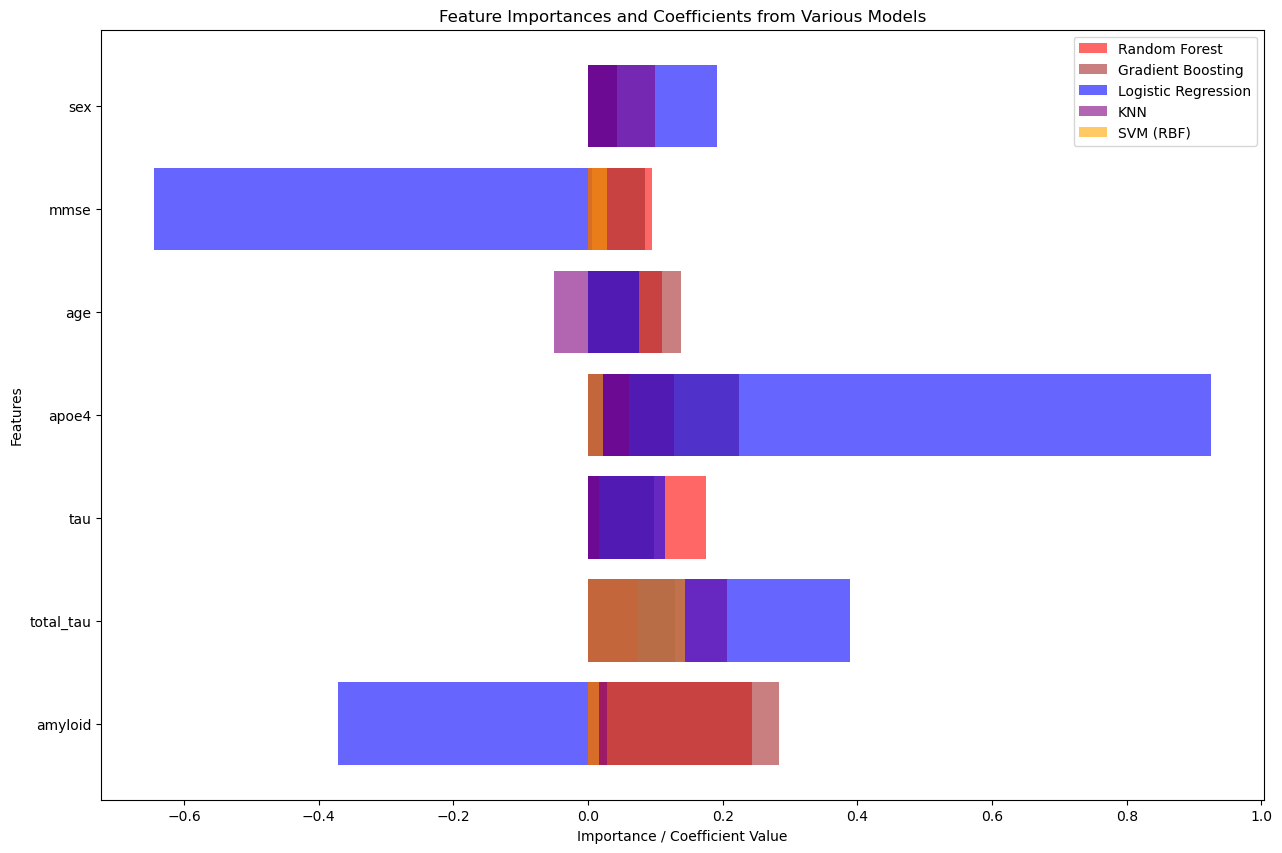

In [20]:
# Plotting the feature importances and coefficients
plt.figure(figsize=(15, 10))

# Plot Random Forest feature importance
plt.barh(feature_importance_rf_df['feature'], feature_importance_rf_df['importance'], color='red', alpha=0.6, label='Random Forest')

# Plot Gradient Boosting feature importance
plt.barh(feature_importance_gb_df['feature'], feature_importance_gb_df['importance'], color='brown', alpha=0.6, label='Gradient Boosting')

# Plot Logistic Regression coefficients
plt.barh(coefficients_logistic_df['feature'], coefficients_logistic_df['coefficient'], color='blue', alpha=0.6, label='Logistic Regression')

# Plot KNN permutation importance
plt.barh(perm_importances_knn['feature'], perm_importances_knn['importance'], color='purple', alpha=0.6, label='KNN')

# Plot SVM (RBF) permutation importance
plt.barh(perm_importances_svm['feature'], perm_importances_svm['importance'], color='orange', alpha=0.6, label='SVM (RBF)')

plt.xlabel('Importance / Coefficient Value')
plt.ylabel('Features')
plt.title('Feature Importances and Coefficients from Various Models')
plt.legend()
plt.show()

## SVM (RBF)


In [21]:
from sklearn.svm import SVC
print(SVC().get_params())

{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': 'deprecated', 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


Summary
Task: Predict whether an MCI patient progresses to Alzheimer's Disease (Target: 1 = Yes, 2 = No) using CSF biomarkers (amyloid, total tau, phosphorylated tau), MMSE cognitive score, and demographics (age, sex, APOE4 status). 89 patients, split 80/20 stratified by outcome (71 train / 18 test).

Models compared: Logistic Regression, Random Forest, SVM (RBF), Gradient Boosting, K-Nearest Neighbors, LDA, and Naive Bayes, combined into a soft-voting VotingClassifier (probability-averaged, since all seven support predict_proba).

Evaluation: Because a false negative here means missing a patient who will progress to Alzheimer's, accuracy alone isn't sufficient. Each model is scored on accuracy, precision, recall, F1, F2 (weights recall 2x precision), and ROC-AUC. GridSearchCV hyperparameter tuning is scored on F2 rather than accuracy, so the search itself favors not missing progressors.

Results:

Before tuning, KNN had the best overall balance (recall 0.80, F2 0.80), with Random Forest close behind on precision (0.875).
Tuning on F2 shifted SVM (RBF) the most — recall rose from 0.70 → 0.90 (F2: 0.71 → 0.85) — the biggest gain in the whole comparison. KNN moved the other way (recall 0.80 → 0.70), a sign that 5-fold CV grid search on ~71 rows doesn't help every model equally, and can overfit small folds for higher-variance methods.
The tuned voting classifier landed at recall 0.70 / F2 0.71 — roughly mid-pack, not better than the best individual tuned model (SVM). The "wisdom of the crowd" didn't outperform the single best-tuned model here, likely because averaging in weaker models (Logistic Regression, LDA) pulled the ensemble down.
Interpretability: Random Forest, Gradient Boosting, and Logistic Regression all rank amyloid and APOE4 among the top predictors — consistent with established Alzheimer's biomarker literature, which is a good sanity check. KNN and SVM's permutation importances disagree more (SVM flags total_tau most strongly), a reminder that with only 18 test rows, importance rankings from different models should be read as suggestive, not definitive.

Caveat: All results are on an 18-row test set — individual metrics can shift by ±1 correct/incorrect prediction ≈ ±0.05-0.1 in any score, so differences between models should be treated as noisy rather than conclusive.

Going by the after-grid-search comparison table (cell 22), and given your stated priority (minimize false negatives):

SVM (RBF) won.

model	recall	f2	f1	precision	accuracy
SVM (RBF)	0.90	0.849	0.783	0.692	0.722
Random Forest	0.70	0.729	0.778	0.875	0.778
Gradient Boosting	0.80	0.755	0.696	0.615	0.611
Voting Classifier	0.70	0.714	0.737	0.778	0.722
Why: SVM has the highest recall (0.9 — it caught 9 out of 10 true progressors in the test set) and the highest F2 score (0.849) of any model, individual or ensemble. That's the direct payoff of switching GridSearchCV's scoring to F2: the search found a C/gamma combination for the SVM that pushed its decision boundary toward flagging more positives, at some cost to precision (0.69 vs. Random Forest's 0.875). Since you said false negatives are the concern, that tradeoff is exactly the one you want — SVM even edges out Random Forest on F1 (0.783 vs 0.778) despite having noticeably worse precision, because its recall advantage is large enough to compensate.

Random Forest is the runner-up and the better choice if precision mattered more (fewer false alarms, best accuracy), and it's also the more stable model across before/after tuning (its numbers barely moved). The voting classifier, despite averaging all seven models, didn't beat the tuned SVM on any metric that matters here — a case where picking the single best-tuned model outperformed "the wisdom of the crowd."

One caveat worth restating: this is an 18-row test set, so "9/10 progressors caught" is one prediction away from "8/10." I'd treat SVM as the better bet, not a settled winner, until validated on more data or with cross-validated recall/F2 rather than a single train/test split.

## Final holdout printout (SVM (RBF), the tuned winner)

Same format as the final holdout evaluation in `lipidomics2.ipynb`, for direct comparison.

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

final_model = best_models['SVM (RBF)']

print(f"Train size: {len(X_train)}  ({y_train.sum()} Yes / {len(y_train) - y_train.sum()} No)")
print(f"Test size:  {len(X_test)}  ({y_test.sum()} Yes / {len(y_test) - y_test.sum()} No)")

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print(pd.DataFrame(cm, index=['Actual: No', 'Actual: Yes'], columns=['Pred: No', 'Pred: Yes']))
print(classification_report(y_test, y_pred, target_names=['No progression', 'Progressed'], digits=3))

tn, fp, fn, tp = cm.ravel()
fnr = fn / (fn + tp) if (fn + tp) > 0 else float('nan')

test_result = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_proba),
    'false_negatives': int(fn),
    'false_negative_rate': fnr,
}
print(test_result)


Train size: 71  (37 Yes / 34 No)
Test size:  18  (10 Yes / 8 No)
             Pred: No  Pred: Yes
Actual: No          4          4
Actual: Yes         1          9
                precision    recall  f1-score   support

No progression      0.800     0.500     0.615         8
    Progressed      0.692     0.900     0.783        10

      accuracy                          0.722        18
     macro avg      0.746     0.700     0.699        18
  weighted avg      0.740     0.722     0.708        18

{'accuracy': 0.7222222222222222, 'precision': 0.6923076923076923, 'auc': 0.73125, 'false_negatives': 1, 'false_negative_rate': np.float64(0.1)}


## The model

Deploy the tuned SVM (RBF) the same way `lipidomics2.ipynb` deploys its Logistic Regression model: fit on the *full* labeled dataset (89 patients, not just the 71-patient train split used for evaluation above) and save it with `joblib`, so the saved model reflects every labeled patient available.

In [32]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_features = list(X.columns)  # age, mmse, amyloid, total_tau, tau, sex, apoe4

# ---- Build and fit on the FULL dataset (all 89 patients) ----
deployable_svm = Pipeline([
    ('sc', StandardScaler()),
    ('clf', SVC(C=0.1, gamma='scale', kernel='rbf', probability=True, random_state=42))
])
deployable_svm.fit(X, y)

# ---- Save to disk ----
joblib.dump(deployable_svm, 'svm_progression_model.joblib')
print("Model saved to svm_progression_model.joblib")

# ---- Also save the feature list, since the model needs columns in this exact order ----
joblib.dump(svm_features, 'svm_progression_model_features.joblib')

Model saved to svm_progression_model.joblib


['svm_progression_model_features.joblib']

# Load the Model

In [24]:
import joblib
import pandas as pd

model = joblib.load('svm_progression_model.joblib')
features = joblib.load('svm_progression_model_features.joblib')

# new_patients must be a DataFrame with the same columns, in the same order
def predict_progression(new_patients_df):
    X_new = new_patients_df[features]
    predictions = model.predict(X_new)
    probabilities = model.predict_proba(X_new)[:, 1]
    return pd.DataFrame({
        'predicted_progression': predictions,
        'progression_probability': probabilities
    }, index=new_patients_df.index)

# example:
# results = predict_progression(new_patients_df)

In [25]:
import pandas as pd

feature_cols = ['age', 'mmse', 'amyloid', 'total_tau', 'tau', 'sex', 'apoe4']

# Same profiles used in lipidomics2.ipynb: amyloid/p-tau vary, everything else held
# at the dataset median (age, mmse, total_tau) or mode (sex, apoe4)
test_array = [
    [73, 27, 368.2,  332.0, 119.2, 0, 0],   # High-risk profile
    [73, 27, 604.0,  332.0, 63.5,  0, 0],   # Median profile
    [73, 27, 1062.0, 332.0, 37.1,  0, 0],   # Low-risk profile
    [73, 27, 257.0,  332.0, 512.0, 0, 0],   # Extreme AD-like
    [73, 27, 1845.0, 332.0, 22.4,  0, 0],   # Extreme low-risk
]
test_labels = ['High-risk profile', 'Median profile', 'Low-risk profile', 'Extreme AD-like', 'Extreme low-risk']

test_patients = pd.DataFrame(test_array, columns=feature_cols, index=test_labels)
test_patients

,age,mmse,amyloid,total_tau,tau,sex,apoe4
High-risk profile,73,27,368.2,332.0,119.2,0,0
Median profile,73,27,604.0,332.0,63.5,0,0
Low-risk profile,73,27,1062.0,332.0,37.1,0,0
Extreme AD-like,73,27,257.0,332.0,512.0,0,0
Extreme low-risk,73,27,1845.0,332.0,22.4,0,0


In [26]:
model = joblib.load('svm_progression_model.joblib')  # adjust path if needed

predictions = model.predict(test_patients)
probabilities = model.predict_proba(test_patients)[:, 1]

results = test_patients.copy()
results['predicted_progression'] = predictions
results['progression_probability'] = probabilities.round(3)

results

,age,mmse,amyloid,total_tau,tau,sex,apoe4,predicted_progression,progression_probability
High-risk profile,73,27,368.2,332.0,119.2,0,0,1,0.433
Median profile,73,27,604.0,332.0,63.5,0,0,0,0.243
Low-risk profile,73,27,1062.0,332.0,37.1,0,0,0,0.130
Extreme AD-like,73,27,257.0,332.0,512.0,0,0,1,0.561
Extreme low-risk,73,27,1845.0,332.0,22.4,0,0,1,0.310
